# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Mon Jun 29 20:35:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'

device

2.11.0+cu128


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?


In [3]:
# Image recognition
# Self driving vehicule
# Disease detection in healthcare

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

In [4]:
# The training data is too small and doesn't contain enough data samples to accurately represent all possible input data values.

# The training data contains large amounts of irrelevant information, known as noisy data.

# The model is training for too long on a sample of the dataset.

# The model's complexity is high, so it learns the noise in the training data.

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [5]:
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
torchvision.__version__

train_data = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)

## 6. Visualize at least 5 different samples of the MNIST training dataset.

In [6]:
image, label = train_data[0]
image, label, image.shape

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [7]:
# How many samples are there?
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [8]:
train_data.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [9]:
test_data.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

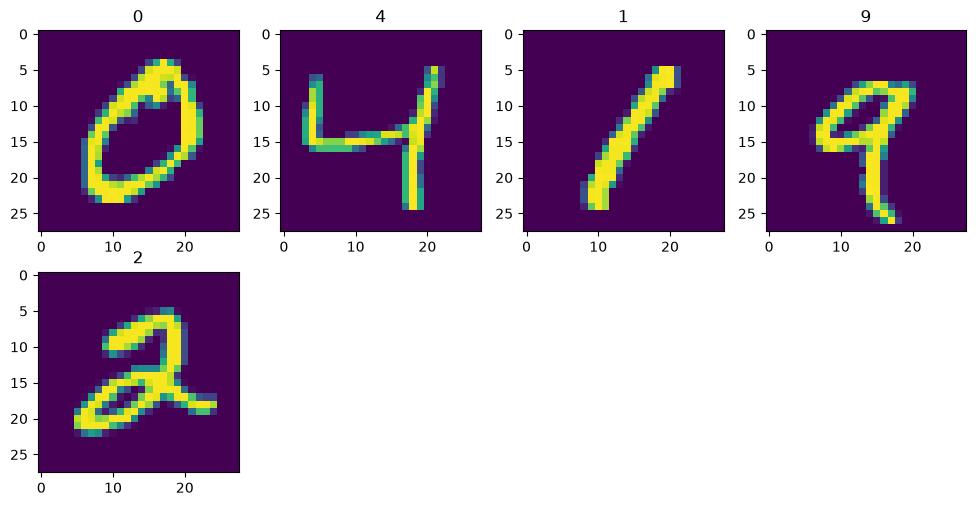

In [10]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(12, 12))
for i in range(1, 6):
  image, label = train_data[i]
  fig.add_subplot(4, 4, i)
  plt.imshow(image.squeeze())
  plt.title(label)

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [11]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_data,
    batch_size = BATCH_SIZE,
    shuffle = True
)

test_dataloader = DataLoader(
    test_data,
    batch_size = BATCH_SIZE
)


# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7f35cce005f0>, <torch.utils.data.dataloader.DataLoader object at 0x7f35cd048f80>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [12]:
from torch import nn

class MNISTModelVGG2(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(
            in_channels=input_shape,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
    )

    self.block_2 = nn.Sequential(
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            padding=1
        ),
        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(
            kernel_size=2,
        )
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(
            in_features=hidden_units*7*7,
            out_features=output_shape
        )
    )

  def forward(self, x: torch.Tensor):
      x = self.block_1(x)
      # print(x.shape)
      x = self.block_2(x)
      # print(x.shape)
      x = self.classifier(x)
      # print(x.shape)
      return x

torch.manual_seed(42)
model_2 = MNISTModelVGG2(input_shape=1,
    hidden_units=10,
    output_shape=len(train_data.classes)).to(device)
model_2

MNISTModelVGG2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [13]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

In [14]:
def train_step(model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    accuracy_fn,
    device: torch.device = device):
  train_loss, train_acc = 0, 0

  model.to(device)
  model.train()
  for batch, (X, y) in enumerate(data_loader):
    # Send data to GPU
    X, y = X.to(device), y.to(device)

    model.train()
    # forward pass
    y_pred = model(X)

    # calculate the loss
    loss = loss_fn(y_pred, y)
    train_loss += loss
    train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    # optimize zero gradient
    optimizer.zero_grad()

    # Loss backward
    loss.backward()

    # Optimizer step
    optimizer.step()

  # Calculate loss and accuracy per epoch and print out what's happening
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

In [15]:
def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X)

            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )

        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [16]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format).
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [17]:
from tqdm.auto import tqdm
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

torch.manual_seed(42)
epochs = 5

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------")
  train_step(
      model=model_2,
      data_loader=train_dataloader,
      loss_fn=nn.CrossEntropyLoss(),
      optimizer=torch.optim.SGD(params=model_2.parameters(), lr=0.1),
      accuracy_fn=accuracy_fn,
      device=device
  )

  test_step(
      model=model_2,
      data_loader=test_dataloader,
      loss_fn=nn.CrossEntropyLoss(),
      accuracy_fn=accuracy_fn,
      device=device
  )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.32091 | Train accuracy: 89.22%
Test loss: 0.07452 | Test accuracy: 97.70%

Epoch: 1
---------
Train loss: 0.08254 | Train accuracy: 97.44%
Test loss: 0.06553 | Test accuracy: 97.89%

Epoch: 2
---------
Train loss: 0.06479 | Train accuracy: 97.99%
Test loss: 0.06033 | Test accuracy: 98.02%

Epoch: 3
---------
Train loss: 0.05635 | Train accuracy: 98.27%
Test loss: 0.05218 | Test accuracy: 98.29%

Epoch: 4
---------
Train loss: 0.05038 | Train accuracy: 98.41%
Test loss: 0.04633 | Test accuracy: 98.35%

Train time on cuda: 63.843 seconds


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [18]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())

    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

In [19]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({train_data.classes[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 2 (2 - two)


In [20]:
# Make predictions on test samples with model 2
pred_probs= make_predictions(model=model_2,
                             data=test_samples)

# View first two prediction probabilities list
pred_probs[:2]

tensor([[5.3206e-11, 4.7696e-06, 9.9999e-01, 2.9708e-06, 1.2182e-14, 7.6486e-15,
         1.3821e-13, 8.3338e-08, 1.4233e-06, 7.9850e-11],
        [5.5072e-07, 9.8703e-01, 7.5315e-05, 2.5326e-06, 1.2729e-05, 6.9941e-03,
         3.0739e-03, 1.2995e-05, 2.6600e-03, 1.3785e-04]])

In [21]:
# Turn the prediction probabilities into prediction labels by taking the argmax()
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([2, 1, 2, 4, 6, 6, 4, 9, 1])

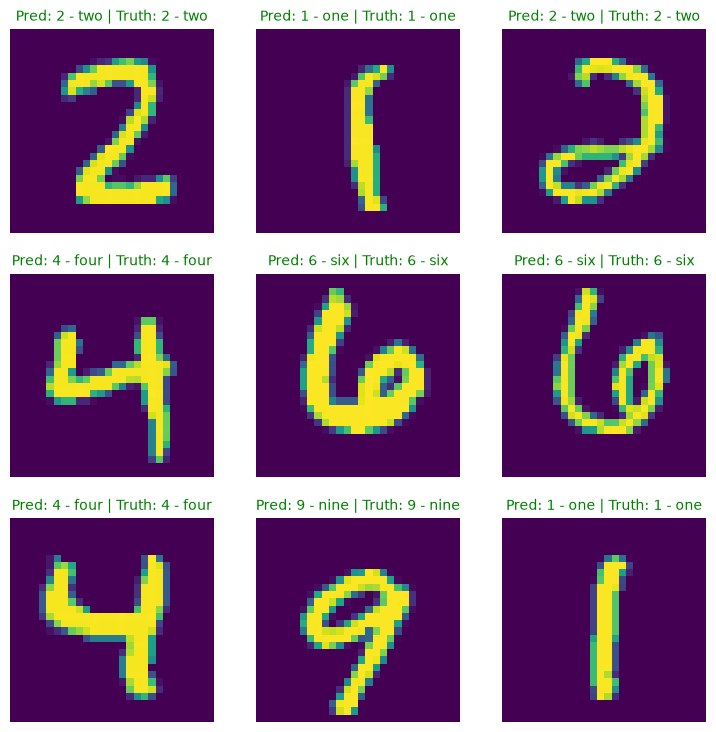

In [22]:
# Plot predictions
plt.figure(figsize=(9, 9))
class_names = train_data.classes
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze())

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_names[pred_classes[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]]

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [23]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model_2(X)
    # Turn predictions from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

In [24]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.25.0


In [25]:
# Import mlxtend upgraded version
import mlxtend
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # should be version 0.19.0 or higher

0.25.0


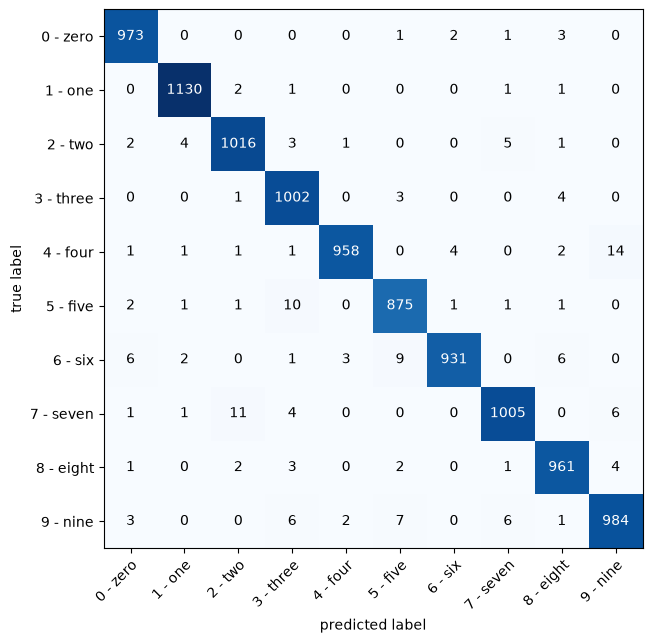

In [26]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib likes working with NumPy
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10, 7)
);

In [27]:
y_pred_tensor

tensor([7, 2, 1,  ..., 4, 5, 6])

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [28]:
torch.manual_seed(42)

# Create sample batch of random numbers with same size as image batch
images = torch.randn(size=(1, 3, 64, 64)) # [batch_size, color_channels, height, width]
test_image = images[0] # get a single image for testing




In [29]:
# Create a convolutional layer with same dimensions as TinyVGG
# (try changing any of the parameters and see what happens)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=1,
                       stride=4,
                       padding=0) # also try using "valid" or "same" here

# Pass the data through the convolutional layer
conv_tensor_layer = conv_layer(test_image)
conv_tensor_layer

tensor([[[-0.2392, -0.5306, -0.0183,  ..., -1.2259, -0.1254, -0.3639],
         [-0.1625, -0.5022, -0.6796,  ...,  0.2335,  0.0813, -0.8943],
         [-0.2631, -0.1012, -0.3862,  ..., -1.0177,  0.3878,  0.1059],
         ...,
         [-0.4234, -0.5148, -0.3226,  ..., -0.4390, -0.1483, -1.0425],
         [-0.6126, -0.9633, -0.4785,  ..., -0.8889, -0.8547, -0.4436],
         [-1.9807, -1.1485, -0.5021,  ..., -1.0761, -2.0043, -0.8861]],

        [[ 0.1935,  0.1851,  0.2880,  ..., -1.0453, -0.1095, -0.3291],
         [-0.1247,  0.9843, -0.7582,  ...,  0.6699,  0.2960, -0.1111],
         [-0.2296, -0.3543, -0.7021,  ..., -0.1633,  1.2871, -1.0152],
         ...,
         [-1.2639,  0.3675,  0.1605,  ..., -0.9032,  0.2365,  0.9625],
         [-0.1916,  0.1420, -0.4365,  ..., -0.7165, -0.3958, -1.1792],
         [-0.8033, -0.1522, -0.4141,  ..., -0.5285, -1.1647, -0.1505]],

        [[ 1.2829,  0.6677,  0.3497,  ..., -0.8628, -0.2114,  0.0814],
         [ 0.0533,  0.3337, -0.9192,  ...,  1

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [30]:
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

fashion_mnist_train = datasets.FashionMNIST(
    download= True,
    root="data",
    train=True,
    transform=transforms.ToTensor()
)

fashion_mnist_test = datasets.FashionMNIST(
    download= True,
    root="data",
    train=False,
    transform=transforms.ToTensor()
)

In [31]:
fashion_mnist_class_names = fashion_mnist_train.classes
fashion_mnist_class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [32]:
fashion_mnist_train_dataloader = DataLoader(
    fashion_mnist_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

fashion_mnist_test_dataloader = DataLoader(
    fashion_mnist_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [33]:
len(fashion_mnist_train_dataloader), len(fashion_mnist_test_dataloader)

(1875, 313)

In [34]:
model_3 = MNISTModelVGG2(
    input_shape=1,
    hidden_units=10,
    output_shape=len(fashion_mnist_train.classes)
    ).to(device)

In [35]:
from tqdm.auto import tqdm
from timeit import default_timer as timer

# 1. Make predictions with trained model
epochs = 5

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)

torch.manual_seed(42)

train_time_start_on_gpu = timer()

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}")

  train_step(
      model=model_3,
      data_loader=fashion_mnist_train_dataloader,
      loss_fn=loss_fn,
      optimizer=optimizer,
      accuracy_fn=accuracy_fn,
      device=device
  )

  test_step(
      model=model_3,
      data_loader=fashion_mnist_test_dataloader,
      loss_fn=loss_fn,
      accuracy_fn=accuracy_fn,
      device=device
  )

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
Train loss: 0.59658 | Train accuracy: 78.21%
Test loss: 0.40124 | Test accuracy: 85.87%

Epoch: 1
Train loss: 0.36706 | Train accuracy: 86.75%
Test loss: 0.36564 | Test accuracy: 86.67%

Epoch: 2
Train loss: 0.32603 | Train accuracy: 88.31%
Test loss: 0.34810 | Test accuracy: 87.61%

Epoch: 3
Train loss: 0.30774 | Train accuracy: 88.80%
Test loss: 0.32671 | Test accuracy: 88.13%

Epoch: 4
Train loss: 0.29449 | Train accuracy: 89.28%
Test loss: 0.31493 | Test accuracy: 88.83%

Train time on cuda: 63.354 seconds


In [36]:
test_preds = []
model_3.eval()
with torch.inference_mode():
  for X, y in fashion_mnist_test_dataloader:
    X, y = X.to(device), y.to(device)
    y_logits = model_3(X)
    y_pred_probs = torch.softmax(y_logits, dim=1)
    y_pred_labels = y_pred_probs.argmax(dim=1)
    test_preds.append(y_pred_labels)

test_preds = torch.cat(test_preds).cpu()


In [37]:
test_preds[:10], len(test_preds), len(fashion_mnist_test_dataloader)

(tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7]), 10000, 313)

In [38]:
import numpy as np

#Get wrong prediction indexes
wrong_predictions = np.where(test_preds != fashion_mnist_test.targets)[0]


In [39]:
wrong_predictions, len(wrong_predictions)

(array([  12,   17,   23, ..., 9972, 9977, 9981], shape=(1119,)), 1119)

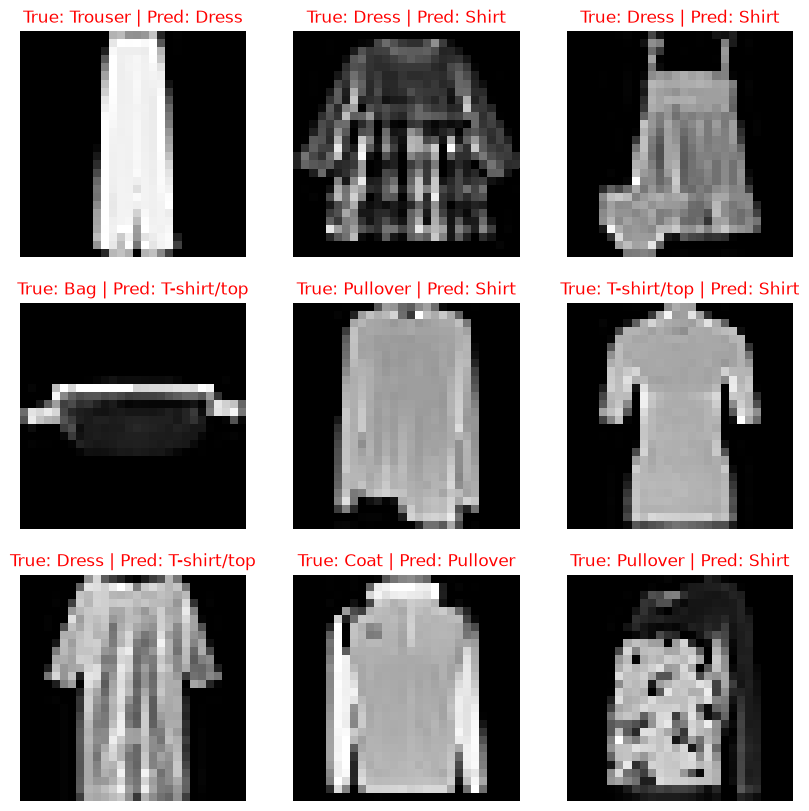

In [40]:
# Select random 9 wrong predictions and plot them
import random
import matplotlib.pyplot as plt

random_selection = random.sample(list(wrong_predictions), k=9)
plt.figure(figsize=(10, 10))
for i, index in enumerate(random_selection):
  true_label = fashion_mnist_class_names[fashion_mnist_test[index][1]]
  pred_label = fashion_mnist_class_names[test_preds[index]]
  plt.subplot(3, 3, i+1)
  plt.imshow(fashion_mnist_test[index][0].squeeze(), cmap="gray")
  plt.title(f"True: {true_label} | Pred: {pred_label}", c="r")
  plt.axis(False);
